# Seatwork 10.1

Group Members: Ruzyl Bryan V. Amora, Alvin John Dano<br>
Section: CPE22S3

### Extract:



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('/content/drive/MyDrive/RT_IOT2022.csv')

print(df.shape)
df.head()

(123117, 85)


,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Transform:

In [4]:
print("Missing values per column:\n", df.isnull().sum())

df = df.dropna(subset=['Attack_type'])

df = df.drop_duplicates()

print("\nAfter cleaning, shape:", df.shape)

print("\nData types:\n", df.dtypes)

Missing values per column:
 no                      0
id.orig_p               0
id.resp_p               0
proto                   0
service                 0
                       ..
idle.std                0
fwd_init_window_size    0
bwd_init_window_size    0
fwd_last_window_size    0
Attack_type             0
Length: 85, dtype: int64

After cleaning, shape: (123117, 85)

Data types:
 no                        int64
id.orig_p                 int64
id.resp_p                 int64
proto                    object
service                  object
                         ...   
idle.std                float64
fwd_init_window_size      int64
bwd_init_window_size      int64
fwd_last_window_size      int64
Attack_type              object
Length: 85, dtype: object


### Load:

In [6]:
df.to_csv('RT_IoT2022_cleaned.csv', index=False)

## Guide Questions:

What is the distribution of the Attack_type classes (normal vs. various attacks), and what percentage of the 123,117 instances does each class comprise?


Attack type distribution:
                            Count  Percentage
Attack_type                                  
DOS_SYN_Hping               94659       76.89
Thing_Speak                  8108        6.59
ARP_poisioning               7750        6.29
MQTT_Publish                 4146        3.37
NMAP_UDP_SCAN                2590        2.10
NMAP_XMAS_TREE_SCAN          2010        1.63
NMAP_OS_DETECTION            2000        1.62
NMAP_TCP_scan                1002        0.81
DDOS_Slowloris                534        0.43
Wipro_bulb                    253        0.21
Metasploit_Brute_Force_SSH     37        0.03
NMAP_FIN_SCAN                  28        0.02


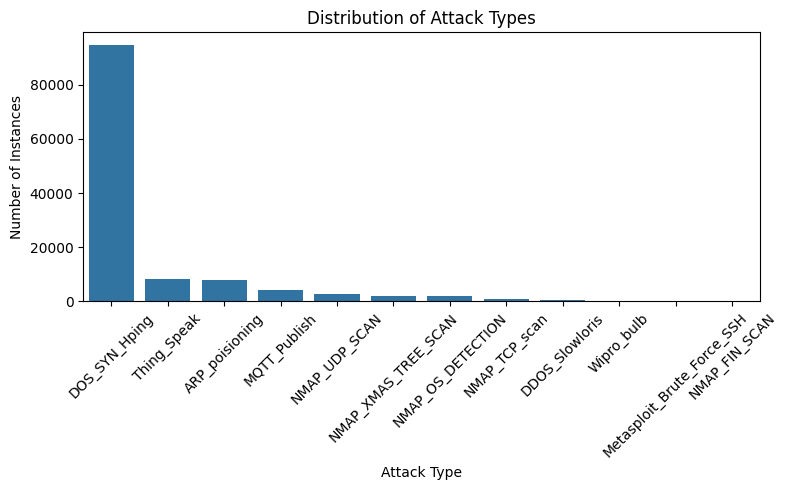

In [7]:
attack_counts = df['Attack_type'].value_counts()
attack_percent = df['Attack_type'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'Count': attack_counts,
    'Percentage': attack_percent.round(2)
})
print("Attack type distribution:")
print(summary)

plt.figure(figsize=(8,5))
sns.barplot(x=attack_counts.index, y=attack_counts.values)
plt.title('Distribution of Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Number of Instances')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

How do the categorical features proto (protocol) and service vary across different attack types and normal traffic patterns? Links to an external site.

In [8]:
print("Unique protocols:", df['proto'].unique())
print("Unique services:", df['service'].unique())

proto_attack = pd.crosstab(df['proto'], df['Attack_type'], normalize='index') * 100
print("\nProtocol distribution (%) per Attack Type:")
print(proto_attack.round(2))

service_attack = pd.crosstab(df['service'], df['Attack_type'], normalize='index') * 100
print("\nService distribution (%) per Attack Type:")
print(service_attack.round(2))

Unique protocols: ['tcp' 'udp' 'icmp']
Unique services: ['mqtt' '-' 'http' 'dns' 'ntp' 'ssl' 'dhcp' 'irc' 'ssh' 'radius']

Protocol distribution (%) per Attack Type:
Attack_type  ARP_poisioning  DDOS_Slowloris  DOS_SYN_Hping  MQTT_Publish  \
proto                                                                      
icmp                  14.04            0.00           0.00          0.00   
tcp                    1.75            0.48          85.72          3.75   
udp                   46.03            0.04           0.00          0.00   

Attack_type  Metasploit_Brute_Force_SSH  NMAP_FIN_SCAN  NMAP_OS_DETECTION  \
proto                                                                       
icmp                               0.00           0.00               0.00   
tcp                                0.03           0.02               1.81   
udp                                0.06           0.02               0.00   

Attack_type  NMAP_TCP_scan  NMAP_UDP_SCAN  NMAP_XMAS_TREE_SCAN  Thi

What are the mean and standard deviation of flow_duration for each Attack_type, and are differences statistically significant?

Mean and standard deviation of flow_duration per attack type:
                              mean      std
Attack_type                                
ARP_poisioning               15.89   108.26
DDOS_Slowloris               14.70    14.12
DOS_SYN_Hping                 0.00     0.00
MQTT_Publish                 43.40    24.34
Metasploit_Brute_Force_SSH    3.01     5.21
NMAP_FIN_SCAN                 0.02     0.11
NMAP_OS_DETECTION             0.00     0.00
NMAP_TCP_scan                 0.00     0.00
NMAP_UDP_SCAN                 0.74    24.91
NMAP_XMAS_TREE_SCAN           0.00     0.05
Thing_Speak                   0.93     5.25
Wipro_bulb                  586.85  2738.89


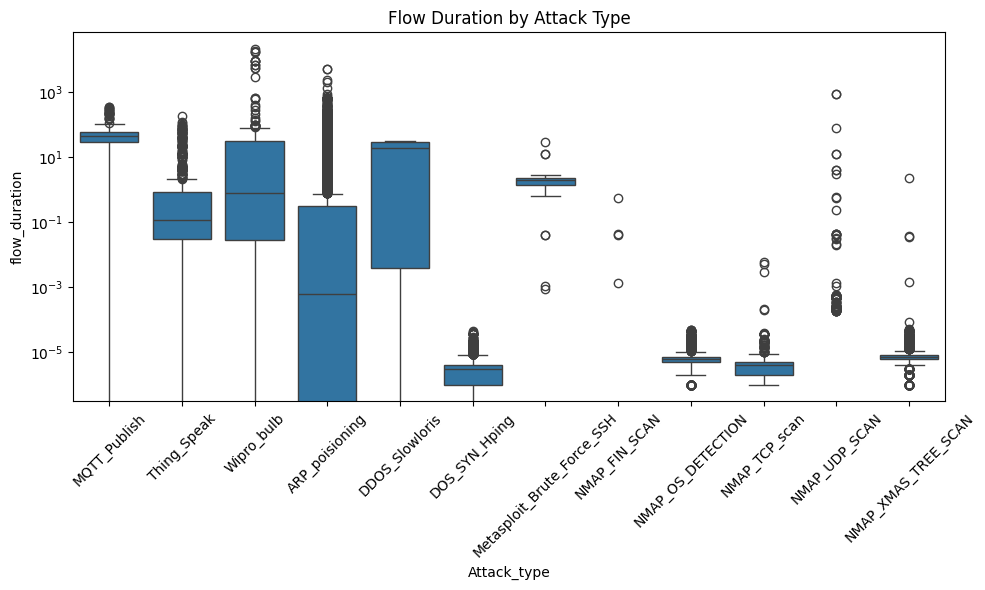


ANOVA result: F-statistic = 536.761, p-value = 0.000e+00
The differences in flow duration among attack types are statistically significant.


In [9]:
duration_stats = df.groupby('Attack_type')['flow_duration'].agg(['mean', 'std']).round(2)
print("Mean and standard deviation of flow_duration per attack type:")
print(duration_stats)

plt.figure(figsize=(10,6))
sns.boxplot(x='Attack_type', y='flow_duration', data=df)
plt.title('Flow Duration by Attack Type')
plt.xticks(rotation=45)
plt.yscale('log')
plt.tight_layout()
plt.show()

df_duration = df.dropna(subset=['flow_duration'])
groups = [group['flow_duration'].values for name, group in df_duration.groupby('Attack_type')]
f_stat, p_value = stats.f_oneway(*groups)

print(f"\nANOVA result: F-statistic = {f_stat:.3f}, p-value = {p_value:.3e}")
if p_value < 0.05:
    print("The differences in flow duration among attack types are statistically significant.")
else:
    print("No significant difference in flow duration among attack types.")

Which continuous features (e.g., fwd_pkts_per_sec, bwd_pkts_per_sec, payload_bytes_per_second) exhibit the highest correlation with specific attack classes?


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Attack_type_encoded'] = le.fit_transform(df['Attack_type'])

continuous_features = [
    'fwd_pkts_per_sec',
    'bwd_pkts_per_sec',
    'payload_bytes_per_second',
    'flow_duration',
    'flow_pkts_per_sec'
]

correlation = df[continuous_features + ['Attack_type_encoded']].corr()

corr_with_target = correlation['Attack_type_encoded'].sort_values(ascending=False)
print(corr_with_target)

Attack_type_encoded         1.000000
flow_duration               0.024384
fwd_pkts_per_sec           -0.251517
flow_pkts_per_sec          -0.251550
bwd_pkts_per_sec           -0.251580
payload_bytes_per_second   -0.296198
Name: Attack_type_encoded, dtype: float64



How do time‑based features like fwd_iat.avg and bwd_iat.avg (mean inter‑arrival times) differ between various attack types and normal traffic?

/tmp/ipykernel_12991/3025982171.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_stats = df.groupby('Attack_type')[time_features].agg(['mean', 'std'])


                             fwd_iat.avg                 bwd_iat.avg  \
                                    mean           std          mean   
Attack_type                                                            
ARP_poisioning              7.443455e+05  6.080604e+06  7.664256e+05   
DDOS_Slowloris              2.660823e+06  2.505477e+06  2.523958e+06   
DOS_SYN_Hping               0.000000e+00  0.000000e+00  0.000000e+00   
MQTT_Publish                4.941675e+06  2.703778e+06  5.222072e+05   
Metasploit_Brute_Force_SSH  4.313227e+05  1.071899e+06  9.100383e+05   
NMAP_FIN_SCAN               4.114728e+03  2.176702e+04  6.539123e+03   
NMAP_OS_DETECTION           0.000000e+00  0.000000e+00  0.000000e+00   
NMAP_TCP_scan               7.311979e+00  1.345700e+02  0.000000e+00   
NMAP_UDP_SCAN               1.436467e+04  4.294105e+05  1.786866e+02   
NMAP_XMAS_TREE_SCAN         1.874295e+02  8.402341e+03  1.716461e+02   
Thing_Speak                 1.186232e+05  8.328482e+05  9.726068

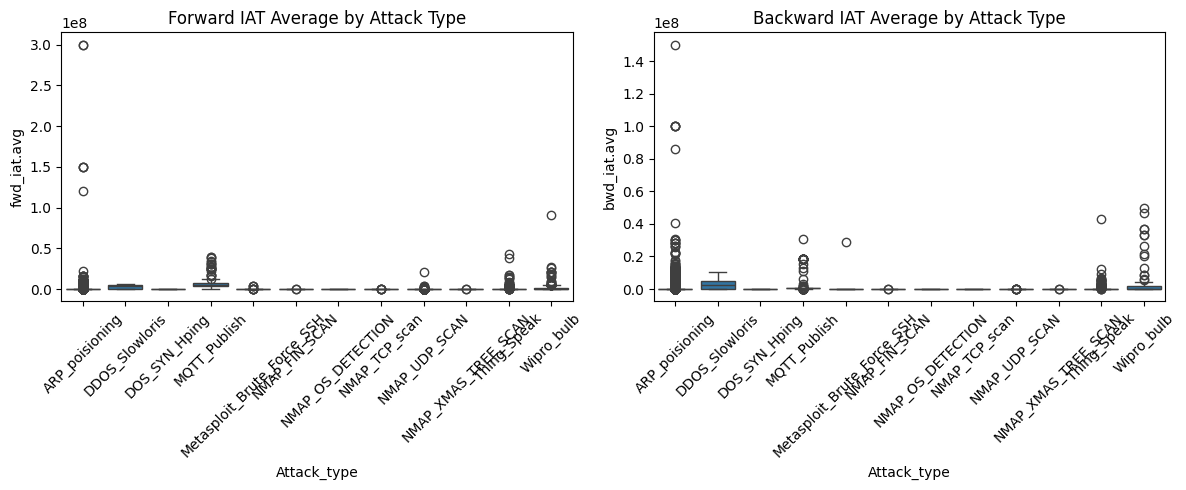

/tmp/ipykernel_12991/3025982171.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_values = df.groupby('Attack_type')[time_features].mean()


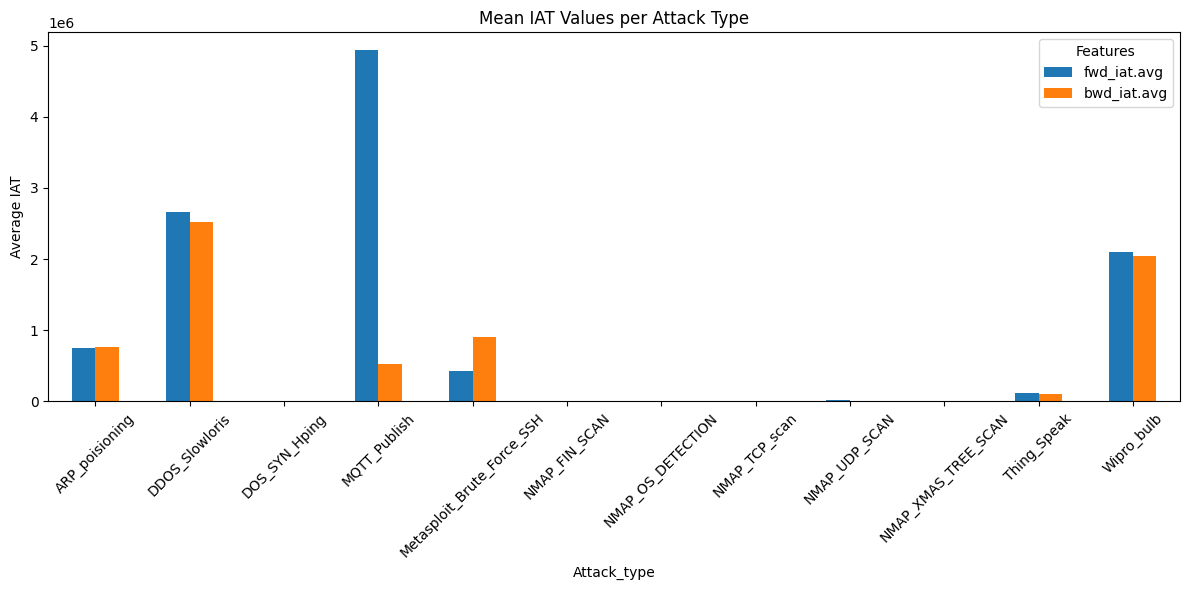

/tmp/ipykernel_12991/3025982171.py:38: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='fwd_iat.avg', hue='Attack_type', fill=True)


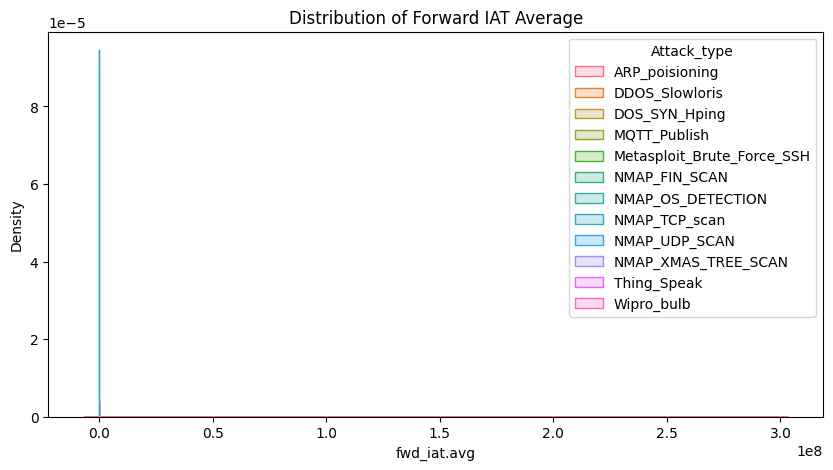

/tmp/ipykernel_12991/3025982171.py:43: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='bwd_iat.avg', hue='Attack_type', fill=True)


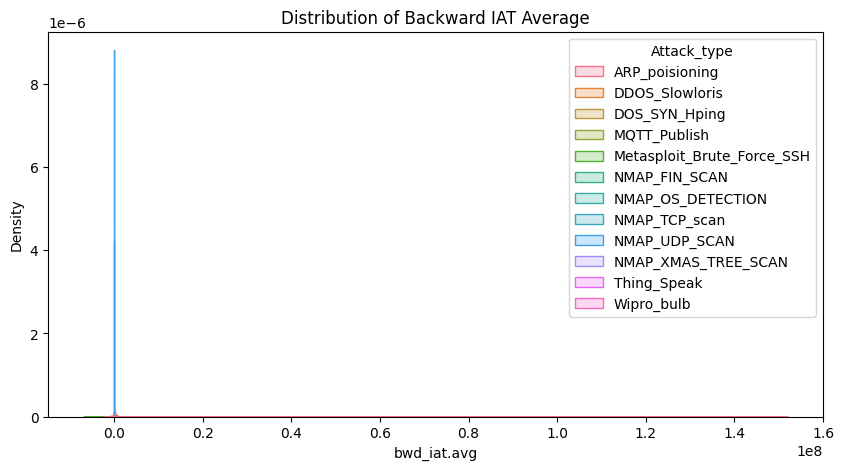

In [14]:
df['Attack_type'] = df['Attack_type'].astype('category')
time_features = ['fwd_iat.avg', 'bwd_iat.avg']

# 1. DESCRIPTIVE STATISTICS
time_stats = df.groupby('Attack_type')[time_features].agg(['mean', 'std'])
print(time_stats)

# 2. BOXPLOT
plt.figure(figsize=(12,5))

# Forward IAT
plt.subplot(1,2,1)
sns.boxplot(x='Attack_type', y='fwd_iat.avg', data=df)
plt.xticks(rotation=45)
plt.title('Forward IAT Average by Attack Type')

# Backward IAT
plt.subplot(1,2,2)
sns.boxplot(x='Attack_type', y='bwd_iat.avg', data=df)
plt.xticks(rotation=45)
plt.title('Backward IAT Average by Attack Type')

plt.tight_layout()
plt.show()

# 3. BAR CHART (MEAN VALUES)
mean_values = df.groupby('Attack_type')[time_features].mean()

mean_values.plot(kind='bar', figsize=(12,6))
plt.title('Mean IAT Values per Attack Type')
plt.ylabel('Average IAT')
plt.xticks(rotation=45)
plt.legend(title="Features")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
sns.kdeplot(data=df, x='fwd_iat.avg', hue='Attack_type', fill=True)
plt.title('Distribution of Forward IAT Average')
plt.show()

plt.figure(figsize=(10,5))
sns.kdeplot(data=df, x='bwd_iat.avg', hue='Attack_type', fill=True)
plt.title('Distribution of Backward IAT Average')
plt.show()



Which network flag counts (e.g., flow_SYN_flag_count, flow_RST_flag_count, fwd_PSH_flag_count) are most indicative of specific intrusion patterns?

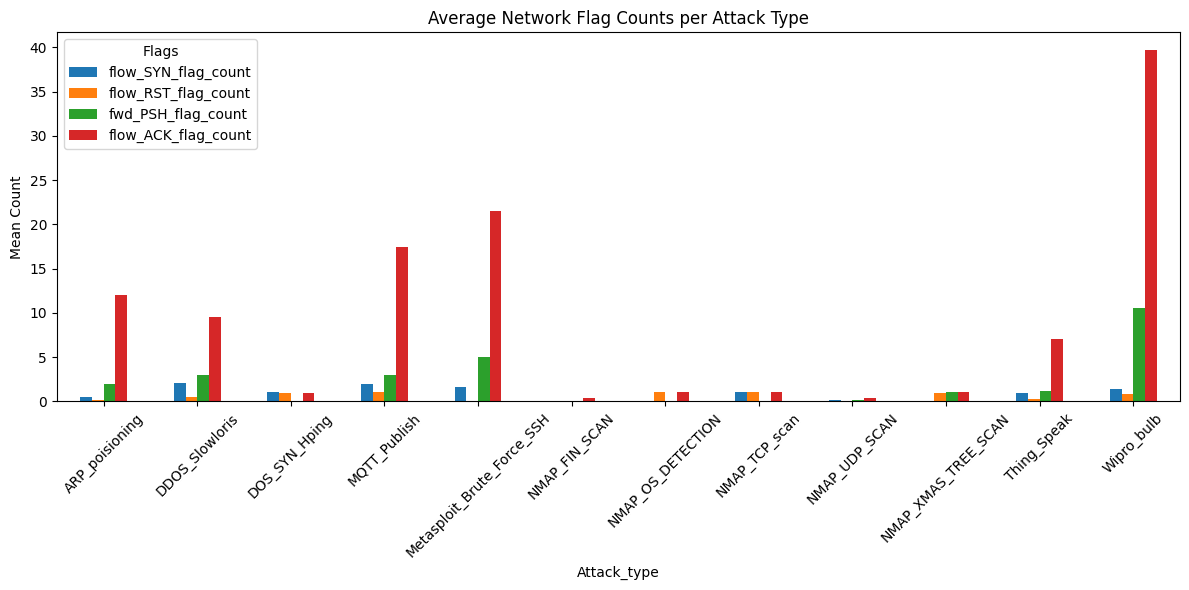

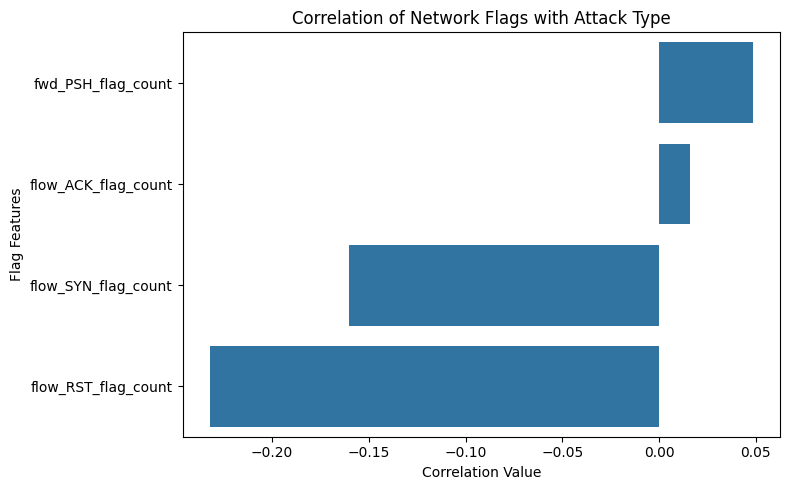

In [13]:
flag_features = [
    'flow_SYN_flag_count',
    'flow_RST_flag_count',
    'fwd_PSH_flag_count',
    'flow_ACK_flag_count'
]

flag_stats = df.groupby('Attack_type')[flag_features].mean()

flag_stats.plot(kind='bar', figsize=(12,6))
plt.title('Average Network Flag Counts per Attack Type')
plt.ylabel('Mean Count')
plt.xticks(rotation=45)
plt.legend(title="Flags")
plt.tight_layout()
plt.show()

le = LabelEncoder()
df['Attack_type_encoded'] = le.fit_transform(df['Attack_type'])
flag_corr = df[flag_features + ['Attack_type_encoded']].corr()
corr_values = flag_corr['Attack_type_encoded'].drop('Attack_type_encoded').sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=corr_values.values,
    y=corr_values.index
)

plt.title("Correlation of Network Flags with Attack Type")
plt.xlabel("Correlation Value")
plt.ylabel("Flag Features")

plt.tight_layout()
plt.show()